# Preparação dos dados

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import warnings

from matplotlib import pyplot as plt
from scipy.stats import chi2
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore")
np.random.seed(42)

In [2]:
def comparar_modelos(modelo_base, modelo_candidato, nome_candidato="Modelo candidato", alpha=0.05):
    """Compara dois modelos aninhados por AIC, BIC e teste LR de qui-quadrado."""
    nome_base = "Modelo base"
    lr = 2 * (modelo_candidato.llf - modelo_base.llf)
    gl = int(round(modelo_candidato.df_model - modelo_base.df_model))

    if gl <= 0:
        raise ValueError("O modelo candidato deve ter mais parâmetros que o modelo base.")
    if lr < -1e-8:
        raise ValueError("LR negativo: confirme se os modelos são aninhados e usam as mesmas observações.")

    lr = max(lr, 0.0)
    p_valor = chi2.sf(lr, gl)
    comparacao = pd.DataFrame(
        {
            "Log-verossimilhança": [modelo_base.llf, modelo_candidato.llf],
            "Parâmetros": [modelo_base.df_model + 1, modelo_candidato.df_model + 1],
            "AIC": [modelo_base.aic, modelo_candidato.aic],
            "ΔAIC vs. base": [0.0, modelo_candidato.aic - modelo_base.aic],
            "BIC": [modelo_base.bic, modelo_candidato.bic],
            "ΔBIC vs. base": [0.0, modelo_candidato.bic - modelo_base.bic],
        },
        index=[nome_base, nome_candidato],
    )

    decisao = (
        f"Evidência de melhora sobre o modelo base (p < {alpha:g})."
        if p_valor < alpha
        else f"Sem evidência de melhora sobre o modelo base (p ≥ {alpha:g})."
    )
    teste_lr = pd.DataFrame(
        {"LR (χ²)": [lr], "gl": [gl], "p-valor": [p_valor], "Decisão": [decisao]},
        index=[f"{nome_candidato} vs. {nome_base}"],
    )

    display(
        comparacao.style
        .format({
            "Log-verossimilhança": "{:.3f}", "Parâmetros": "{:.0f}",
            "AIC": "{:.3f}", "ΔAIC vs. base": "{:+.3f}",
            "BIC": "{:.3f}", "ΔBIC vs. base": "{:+.3f}",
        })
        .highlight_min(subset=["AIC", "BIC"], color="#1f5c0a")
        .set_caption("Comparação do ajuste — menores AIC/BIC são preferíveis")
    )
    display(
        teste_lr.style
        .format({"LR (χ²)": "{:.3f}", "gl": "{:.0f}", "p-valor": "{:.3e}"})
        .map(
            lambda valor: "background-color: #1f5c0a" if valor < alpha else "background-color: #ad2f2f",
            subset=["p-valor"],
        )
        .set_caption("Teste da razão de verossimilhanças (H₀: o modelo base é suficiente)")
    )

    return {"comparacao": comparacao, "teste_lr": teste_lr}


In [3]:
df = pd.read_csv('../data/raw/Churn_Modelling.csv', sep=',', na_values=[''], quotechar='"')

In [4]:
df.drop(columns=['CustomerId','RowNumber','Surname'],inplace=True)

In [5]:
y = df["Exited"]
X = df.drop(columns=['Exited'])

# Pressupostos

## Independência

As observações feitas na fase de EDA não evidenciaram dependência entre as variáveis, o pressuposto de independência é assegurado pelo próprio dataset

## Multicolinearidade

In [6]:
X_vif = sm.add_constant(X.select_dtypes(['number']))

vif = pd.DataFrame({
    "Variável": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
})

vif[vif["Variável"] != "const"]


,Variável,VIF
1,CreditScore,1.000984
2,Age,1.009028
3,Tenure,1.001666
4,Balance,1.103281
5,NumOfProducts,1.103382
6,HasCrCard,1.001088
7,IsActiveMember,1.009289
8,EstimatedSalary,1.000853


A avaliação da multicolinearidade foi realizada por meio do Variance Inflation Factor (VIF). Todas as variáveis apresentaram valores muito próximos de 1, indicando ausência de correlação linear significativa entre os preditores. Dessa forma, descarta-se a multicolinearidade como possível causa para a instabilidade observada no ajuste do modelo logístico.

## Linearidade no logit

In [7]:
df_bt = df.copy()



variaveis_continuas = ["Age", "CreditScore", "Balance", "EstimatedSalary"]

for col in variaveis_continuas:
    df_bt[f"ln_{col}"] = np.log(df_bt[col] + 0.001)
    df_bt[f"{col}_ln_{col}"] = df_bt[col] * df_bt[f"ln_{col}"]

termos_originais = " + ".join(variaveis_continuas)
termos_interacao = " + ".join([f"{col}_ln_{col}" for col in variaveis_continuas])
formula = f"Exited ~ {termos_originais} + {termos_interacao}"



modelo_box = smf.logit(formula, data=df_bt).fit()

modelo_box.summary()

Optimization terminated successfully.
         Current function value: 0.442995
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 Exited   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9991
Method:                           MLE   Df Model:                            8
Date:                Sun, 19 Jul 2026   Pseudo R-squ.:                  0.1236
Time:                        15:00:25   Log-Likelihood:                -4430.0
converged:                       True   LL-Null:                       -5054.9
Covariance Type:            nonrobust   LLR p-value:                1.602e-264
======================================================================================================
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                            -11.6567      1.900     -6.134      0.000     -15.381      -7.932
Age                                    1.4672      0.087     16.863      0.000       1.297       1.638
CreditScore                           -0.0630      0.020     -3.106      0.002      -0.103      -0.023
Balance                             4.623e-05   1.43e-05      3.231      0.001    1.82e-05    7.43e-05
EstimatedSalary                    -2.421e-05   1.69e-05     -1.432      0.152   -5.73e-05    8.92e-06
Age_ln_Age                            -0.2902      0.018    -16.179      0.000      -0.325      -0.255
CreditScore_ln_CreditScore             0.0084      0.003      3.072      0.002       0.003       0.014
Balance_ln_Balance                 -3.478e-06    1.2e-06     -2.894      0.004   -5.83e-06   -1.12e-06
EstimatedSalary_ln_EstimatedSalary  1.998e-06   1.37e-06      1.464      0.143   -6.77e-07    4.67e-06
======================================================================================================
"""


O teste de Box-Tidwell indicou violação do pressuposto de linearidade no logit para as variáveis Age, CreditScore e Balance. Entretanto, optou-se por manter essas variáveis em sua forma original por dois motivos:
-  preservar a interpretabilidade do modelo
-  manter a consistência metodológica com os objetivos da atividade, que consiste na aplicação da regressão logística clássica.


### Investigação complementar


Como aproximadamente 36% dos clientes apresentam saldo igual a zero, foi conduzida uma análise adicional para verificar se a violação do pressuposto de linearidade era consequência dessa concentração de valores. O resultado mostrou que o termo de interação permaneceu estatisticamente significativo, indicando que a não linearidade observada não decorre apenas da presença dos saldos nulos.

In [8]:
df_bt["ln_Balance"] = np.nan
df_bt["Balance_ln_Balance"] = np.nan

positivo_idx = df_bt["Balance"] > 0
df_bt.loc[positivo_idx, "ln_Balance"] = np.log(df_bt.loc[positivo_idx, "Balance"])
df_bt.loc[positivo_idx, "Balance_ln_Balance"] = df_bt.loc[positivo_idx, "Balance"] * df_bt.loc[positivo_idx, "ln_Balance"]

df_bt["Balance_ln_Balance"] = df_bt["Balance_ln_Balance"].fillna(0)

smf.logit('Exited ~  Balance + Balance_ln_Balance', data=df_bt).fit().summary()


Optimization terminated successfully.
         Current function value: 0.497699
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 Exited   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9997
Method:                           MLE   Df Model:                            2
Date:                Sun, 19 Jul 2026   Pseudo R-squ.:                 0.01541
Time:                        15:00:25   Log-Likelihood:                -4977.0
converged:                       True   LL-Null:                       -5054.9
Covariance Type:            nonrobust   LLR p-value:                 1.471e-34
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -1.8217      0.048    -38.061      0.000      -1.915      -1.728
Balance             5.335e-05   1.35e-05      3.962      0.000     2.7e-05    7.97e-05
Balance_ln_Balance -4.073e-06   1.13e-06     -3.603      0.000   -6.29e-06   -1.86e-06
======================================================================================
"""

## Complete Separation

No EDA identificou separação completa na categoria de clientes com quatro produtos, uma vez que todas as 60 observações desse grupo apresentaram churn. Esse comportamento pode impedir a estimação finita do coeficiente pela regressão logística convencional

Para validação da hipótese optou-se por criar um modelo com as variáveis abaixo e analisar em conjunto a ausência de convergência, erro-padrão, intervalo de confiança e validade do Teste de Wald

```
Exited ~ CreditScore
       + C(Geography)
       + C(Gender)
       + Age
       + Tenure
       + Balance
       + C(NumOfProducts)
       + HasCrCard
       + IsActiveMember
       + EstimatedSalary
```


In [9]:
formula = """
Exited ~ CreditScore
       + C(Geography)
       + C(Gender)
       + Age
       + Tenure
       + Balance
       + C(NumOfProducts)
       + HasCrCard
       + IsActiveMember
       + EstimatedSalary
"""

modelo_base = smf.logit(formula, data=df).fit()
modelo_base.summary()

         Current function value: 0.371431
         Iterations: 35


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 Exited   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9986
Method:                           MLE   Df Model:                           13
Date:                Sun, 19 Jul 2026   Pseudo R-squ.:                  0.2652
Time:                        15:00:25   Log-Likelihood:                -3714.3
converged:                      False   LL-Null:                       -5054.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -2.8043      0.252    -11.133      0.000      -3.298      -2.311
C(Geography)[T.Germany]     0.9518      0.073     13.051      0.000       0.809       1.095
C(Geography)[T.Spain]       0.0600      0.076      0.790      0.430      -0.089       0.209
C(Gender)[T.Male]          -0.5226      0.059     -8.861      0.000      -0.638      -0.407
C(NumOfProducts)[T.2]      -1.5466      0.071    -21.716      0.000      -1.686      -1.407
C(NumOfProducts)[T.3]       2.5679      0.180     14.278      0.000       2.215       2.920
C(NumOfProducts)[T.4]      21.7625   4365.105      0.005      0.996   -8533.686    8577.211
CreditScore                -0.0007      0.000     -2.289      0.022      -0.001   -9.97e-05
Age                         0.0713      0.003     25.808      0.000       0.066       0.077
Tenure                     -0.0196      0.010     -1.940      0.052      -0.039       0.000
Balance                 -7.027e-07    5.7e-07     -1.233      0.217   -1.82e-06    4.14e-07
HasCrCard                  -0.0617      0.064     -0.961      0.337      -0.187       0.064
IsActiveMember             -1.1058      0.062    -17.736      0.000      -1.228      -0.984
EstimatedSalary          4.393e-07   5.13e-07      0.856      0.392   -5.67e-07    1.45e-06
===========================================================================================
"""


Durante o ajuste do modelo foi observado que a variável NumOfProducts, quando tratada como categórica, apresentou evidências de separação completa.

Isso ocorreu porque todos os clientes pertencentes à categoria "4 produtos" apresentaram churn, impossibilitando a estimação finita do coeficiente correspondente.

Essa situação produziu:

* ausência de convergência do algoritmo;
* coeficiente extremamente elevado;
* erro-padrão muito grande;
* intervalo de confiança excessivamente amplo;
* perda da validade do teste de Wald para esse parâmetro.

Esses resultados caracterizam o fenômeno conhecido como Complete Separation.

### Correção Complete Separation

Para preservar a estabilidade da estimação e manter a interpretabilidade do modelo, as categorias "3 produtos" e "4 produtos" foram agrupadas em uma única categoria ("3 ou mais produtos"), eliminando a separação completa sem perda significativa de informação.

In [10]:
df["ProductsGroup"] = df["NumOfProducts"].replace({
    1: "1",
    2: "2",
    3: "3+",
    4: "3+",
})

df["ProductsGroup"] = pd.Categorical(df["ProductsGroup"], categories=["1", "2", "3+"])

## Resumo

| Pressuposto                   | Método de Avaliação                         | Resultado                               | Ação                                                    |
|-------------------------------|---------------------------------------------|-----------------------------------------|---------------------------------------------------------|
| Independência das observações | Delineamento do estudo                      | Atendido                                | Nenhuma                                                 |
| Multicolinearidade            | VIF                                         | Atendido                                | Nenhuma                                                 |
| Linearidade no logit          | Box-Tidwell                                 | Violado para Age, CreditScore e Balance | Mantidas pela interpretabilidade; limitação documentada |
| Complete Separation           | Inspeção do ajuste e tabela de contingência | Detectado para `NumOfProducts = 4`      | Agrupamento das categorias 3 e 4                        |


# Modelo Base

In [11]:
formula = """
Exited ~ CreditScore
       + C(Geography)
       + C(Gender)
       + Age
       + Tenure
       + Balance
       + C(ProductsGroup)
       + HasCrCard
       + IsActiveMember
       + EstimatedSalary
"""

modelo_base = smf.logit(formula, data=df).fit()
modelo_base.summary()

Optimization terminated successfully.
         Current function value: 0.372317
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 Exited   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9987
Method:                           MLE   Df Model:                           12
Date:                Sun, 19 Jul 2026   Pseudo R-squ.:                  0.2635
Time:                        15:00:25   Log-Likelihood:                -3723.2
converged:                       True   LL-Null:                       -5054.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -2.8137      0.252    -11.184      0.000      -3.307      -2.321
C(Geography)[T.Germany]     0.9469      0.073     13.005      0.000       0.804       1.090
C(Geography)[T.Spain]       0.0527      0.076      0.693      0.488      -0.096       0.202
C(Gender)[T.Male]          -0.5251      0.059     -8.911      0.000      -0.641      -0.410
C(ProductsGroup)[T.2]      -1.5448      0.071    -21.692      0.000      -1.684      -1.405
C(ProductsGroup)[T.3+]      2.8036      0.175     16.043      0.000       2.461       3.146
CreditScore                -0.0007      0.000     -2.292      0.022      -0.001      -0.000
Age                         0.0714      0.003     25.870      0.000       0.066       0.077
Tenure                     -0.0190      0.010     -1.888      0.059      -0.039       0.001
Balance                 -6.478e-07   5.69e-07     -1.139      0.255   -1.76e-06    4.67e-07
HasCrCard                  -0.0648      0.064     -1.011      0.312      -0.190       0.061
IsActiveMember             -1.1038      0.062    -17.714      0.000      -1.226      -0.982
EstimatedSalary          4.458e-07   5.13e-07      0.869      0.385    -5.6e-07    1.45e-06
===========================================================================================
"""

# Analises dos Resíduos

In [12]:
df["Probabilidade_Prevista"] = modelo_base.predict(df)

In [13]:
df["Residuo_Deviance"] = modelo_base.resid_dev

In [14]:
df["Residuo_Deviance"].describe()

count    10000.000000
mean        -0.130674
std          0.853013
min         -2.605591
25%         -0.586503
50%         -0.360409
75%         -0.178432
max          3.270450
Name: Residuo_Deviance, dtype: float64

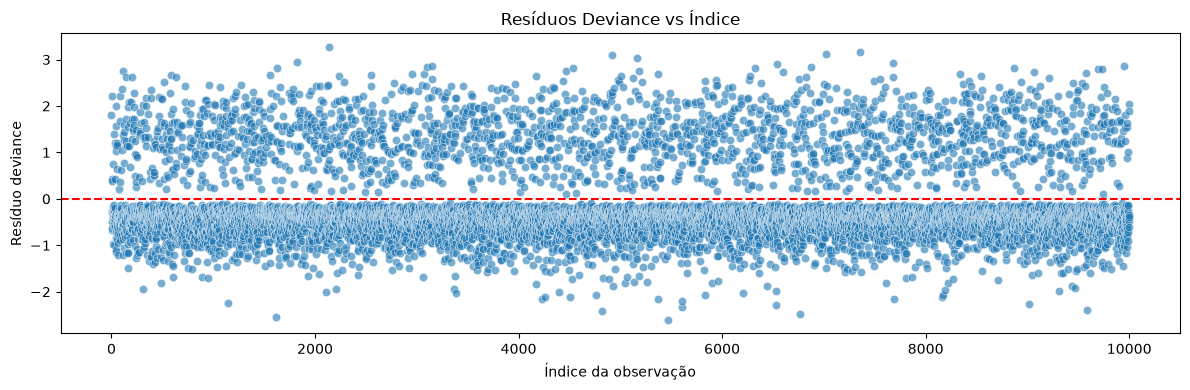

In [15]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12, 4))

sns.scatterplot(x=np.arange(len(modelo_base.resid_dev)), y=modelo_base.resid_dev, alpha=0.6)
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Resíduos Deviance vs Índice")
plt.xlabel("Índice da observação")
plt.ylabel("Resíduo deviance")



plt.tight_layout()
plt.show()



In [16]:
df.sort_values(by="Residuo_Deviance", ascending=False)[["Exited", "Probabilidade_Prevista", "Residuo_Deviance"]].head()


,Exited,Probabilidade_Prevista,Residuo_Deviance
2141,1,0.004758,3.270450
7353,1,0.006522,3.172568
7017,1,0.007711,3.119333
4922,1,0.008409,3.091424
5167,1,0.010175,3.029133


In [17]:
df.sort_values(by="Residuo_Deviance")[["Exited", "Probabilidade_Prevista", "Residuo_Deviance"]].head()


,Exited,Probabilidade_Prevista,Residuo_Deviance
5465,0,0.966444,-2.605591
1614,0,0.961398,-2.551252
6763,0,0.953079,-2.473576
4815,0,0.945025,-2.408681
9587,0,0.943920,-2.400410


### Qual o padrão dos clientes que o modelo errou com tanta confiança?

In [18]:
top20 = df.assign(
    abs_dev=np.abs(df["Residuo_Deviance"])
).nlargest(20, "abs_dev")

In [19]:
top20.groupby("Exited").size()

Exited
1    20
dtype: int64

In [20]:
top20[[
    "Geography",
    "Gender",
    "ProductsGroup",
    "Age",
    "Balance",
    "IsActiveMember"
]]

,Geography,Gender,ProductsGroup,Age,Balance,IsActiveMember
2141,France,Male,2,18,0.00,1
7353,France,Male,2,21,210433.08,1
7017,Spain,Male,2,25,182876.88,1
4922,France,Male,2,26,56738.47,1
5167,France,Male,2,29,0.00,1
1827,Spain,Female,2,22,169649.73,1
7681,France,Male,2,33,146193.60,1
6538,France,Male,2,34,165363.31,1
9947,France,Male,2,34,83503.11,1
3146,France,Female,2,28,116755.50,1


In [21]:
top20.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Probabilidade_Prevista,Residuo_Deviance,abs_dev
count,20.000000,20.000000,20.000000,20.000000,20.0,20.000000,20.0,20.000000,20.0,20.000000,20.000000,20.000000
mean,659.750000,29.700000,4.800000,92104.837000,2.0,0.700000,1.0,80852.973500,1.0,0.015440,2.911357,2.911357
std,95.958256,5.526015,3.122078,80224.516016,0.0,0.470162,0.0,53974.451382,0.0,0.005315,0.147261,0.147261
min,425.000000,18.000000,0.000000,0.000000,2.0,0.000000,1.0,7597.830000,1.0,0.004758,2.755510,2.755510
25%,616.500000,27.500000,2.000000,0.000000,2.0,0.000000,1.0,41134.110000,1.0,0.012427,2.816396,2.816396
50%,662.500000,29.500000,5.000000,97213.130000,2.0,1.000000,1.0,67486.885000,1.0,0.017071,2.853216,2.853216
75%,700.500000,34.000000,7.250000,166434.915000,2.0,1.000000,1.0,109463.880000,1.0,0.018949,2.964180,2.964180
max,850.000000,39.000000,10.000000,210433.080000,2.0,1.000000,1.0,197297.770000,1.0,0.022451,3.270450,3.270450


### Qual a relação escondida nesses clientes?
Os top 20 clientes que pelo análise do EDA são perfis considerados fieis ao banco, no entanto, houve churn.

In [22]:
churn = df[df.Exited == 1]


In [23]:
churn.describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,2037.0,645.351497,100.321503,350.000000,578.000000,646.000000,716.000000,850.000000
Age,2037.0,44.837997,9.761562,18.000000,38.000000,45.000000,51.000000,84.000000
Tenure,2037.0,4.932744,2.936106,0.000000,2.000000,5.000000,8.000000,10.000000
Balance,2037.0,91108.539337,58360.794816,0.000000,38340.020000,109349.290000,131433.330000,250898.090000
NumOfProducts,2037.0,1.475209,0.801521,1.000000,1.000000,1.000000,2.000000,4.000000
HasCrCard,2037.0,0.699067,0.458776,0.000000,0.000000,1.000000,1.000000,1.000000
IsActiveMember,2037.0,0.360825,0.480358,0.000000,0.000000,0.000000,1.000000,1.000000
EstimatedSalary,2037.0,101465.677531,57912.418071,11.580000,51907.720000,102460.840000,152422.910000,199808.100000
Exited,2037.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Probabilidade_Prevista,2037.0,0.432371,0.272162,0.004758,0.204203,0.387682,0.638190,0.995394


In [24]:

df_churn = df[df['Exited'] == 1].copy()

top_20_erros_idx = df_churn.sort_values(by="Residuo_Deviance", ascending=False).head(20).index

df_churn['Grupo'] = 'Restante dos churn'
df_churn.loc[top_20_erros_idx, 'Grupo'] = 'Top 20 erros'

resumo_diagnostico = df_churn.groupby('Grupo').agg(
    idade_media=('Age', 'mean'),
    pct_franca=('Geography', lambda x: (x == 'France').mean() * 100),
    pct_2_produtos=('ProductsGroup', lambda x: (x == '2').mean() * 100),
    pct_ativos=('IsActiveMember', lambda x: (x == 1).mean() * 100),
    balance_medio=('Balance', 'mean')
).T

resumo_diagnostico = resumo_diagnostico[['Top 20 erros', 'Restante dos churn']]

resumo_diagnostico.index = ['Idade média', '% França', '% 2 produtos', '% Ativos', 'Balance médio']

tabela_diagnostico_final = (resumo_diagnostico.style
    .format("{:.1f}", subset=pd.IndexSlice[['Idade média'], :])
    .format("{:.1f}%", subset=pd.IndexSlice[['% França', '% 2 produtos', '% Ativos'], :])
    .format("{:,.2f}", subset=pd.IndexSlice[['Balance médio'], :])
)

tabela_diagnostico_final


Grupo,Top 20 erros,Restante dos churn
Idade média,29.7,45.0
% França,70.0%,39.5%
% 2 produtos,100.0%,16.3%
% Ativos,100.0%,35.4%
Balance médio,"92,104.84","91,098.66"


A análise dos maiores resíduos de deviance revelou um grupo específico de clientes sistematicamente mal classificado pelo modelo. Esses clientes apresentam idade média significativamente inferior (29,7 contra 45 anos), são predominantemente franceses (70%), possuem exatamente dois produtos (100%) e são todos membros ativos. Em contrapartida, o saldo médio mostrou-se praticamente idêntico ao observado no restante dos clientes que realizaram churn, sugerindo que a variável Balance não explica esse padrão de erro. Esses resultados indicam que o modelo pode não capturar adequadamente interações envolvendo idade, atividade do cliente e número de produtos.

In [25]:
mask = (
    (df["ProductsGroup"] == "2") &
    (df["IsActiveMember"] == 1)
)

df.groupby(mask)["Exited"].mean()

False    0.251655
True     0.055601
Name: Exited, dtype: float64

In [26]:
mask = (
    (df["ProductsGroup"] == "2") &
    (df["IsActiveMember"] == 1) &
    (df["Age"] < 35)
)

df.groupby(mask)["Exited"].mean()

False    0.222899
True     0.024768
Name: Exited, dtype: float64

A investigação das observações com maiores resíduos de deviance mostrou que os erros mais extremos ocorreram exclusivamente entre clientes que realizaram churn, embora apresentassem um perfil tipicamente associado à permanência: idade reduzida, dois produtos e condição de membro ativo. A taxa de churn desse segmento foi particularmente baixa, alcançando aproximadamente 5,6% entre clientes ativos com dois produtos e 2,5% quando também considerada idade inferior a 35 anos. Dessa forma, os erros extremos não indicam necessariamente falha sistemática do modelo, mas a ocorrência de eventos raros em um grupo de baixo risco segundo as variáveis disponíveis.

In [27]:
df["Residuo_Pearson"] = modelo_base.resid_pearson

influencia = modelo_base.get_influence()

df["Leverage"] = influencia.hat_matrix_diag
df["Cooks_Distance"] = influencia.cooks_distance[0]

In [28]:
df["Residuo_Pearson"].describe()

count    10000.000000
mean         0.001754
std          1.026852
min         -5.366682
25%         -0.433208
50%         -0.259042
75%         -0.126675
max         14.462739
Name: Residuo_Pearson, dtype: float64

In [29]:
top20_person_resid = df.assign(
    abs_pears=np.abs(df["Residuo_Pearson"])
).nlargest(20, "abs_pears")

top20_person_resid

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ProductsGroup,Probabilidade_Prevista,Residuo_Deviance,Residuo_Pearson,Leverage,Cooks_Distance,abs_pears
2141,674,France,Male,18,7,0.00,2,1,1,55753.12,1,2,0.004758,3.270450,14.462739,0.000077,0.001247,14.462739
7353,596,France,Male,21,4,210433.08,2,0,1,197297.77,1,2,0.006522,3.172568,12.342209,0.000162,0.001903,12.342209
7017,646,Spain,Male,25,5,182876.88,2,1,1,42537.59,1,2,0.007711,3.119333,11.344010,0.000152,0.001505,11.344010
4922,702,France,Male,26,5,56738.47,2,1,1,100442.22,1,2,0.008409,3.091424,10.859104,0.000096,0.000873,10.859104
5167,726,France,Male,29,7,0.00,2,1,1,91844.14,1,2,0.010175,3.029133,9.863082,0.000123,0.000923,9.863082
1827,425,Spain,Female,22,7,169649.73,2,0,1,136365.00,1,2,0.013178,2.942529,8.653693,0.000327,0.001886,8.653693
7681,641,France,Male,33,2,146193.60,2,1,1,55796.83,1,2,0.014085,2.919808,8.366430,0.000189,0.001016,8.366430
6538,546,France,Male,34,4,165363.31,2,1,1,25744.13,1,2,0.015143,2.894907,8.064667,0.000236,0.001180,8.064667
9947,615,France,Male,34,1,83503.11,2,1,1,73124.53,1,2,0.016438,2.866417,7.735338,0.000179,0.000826,7.735338
3146,548,France,Female,28,8,116755.50,2,1,1,158585.17,1,2,0.016870,2.857355,7.634003,0.000237,0.001062,7.634003


In [30]:
top20_person_resid.groupby('Exited').size()

Exited
1    20
dtype: int64

In [31]:
top20_person_resid.describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,20.0,659.750000,95.958256,425.000000,616.500000,662.500000,700.500000,850.000000
Age,20.0,29.700000,5.526015,18.000000,27.500000,29.500000,34.000000,39.000000
Tenure,20.0,4.800000,3.122078,0.000000,2.000000,5.000000,7.250000,10.000000
Balance,20.0,92104.837000,80224.516016,0.000000,0.000000,97213.130000,166434.915000,210433.080000
NumOfProducts,20.0,2.000000,0.000000,2.000000,2.000000,2.000000,2.000000,2.000000
HasCrCard,20.0,0.700000,0.470162,0.000000,0.000000,1.000000,1.000000,1.000000
IsActiveMember,20.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
EstimatedSalary,20.0,80852.973500,53974.451382,7597.830000,41134.110000,67486.885000,109463.880000,197297.770000
Exited,20.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Probabilidade_Prevista,20.0,0.015440,0.005315,0.004758,0.012427,0.017071,0.018949,0.022451


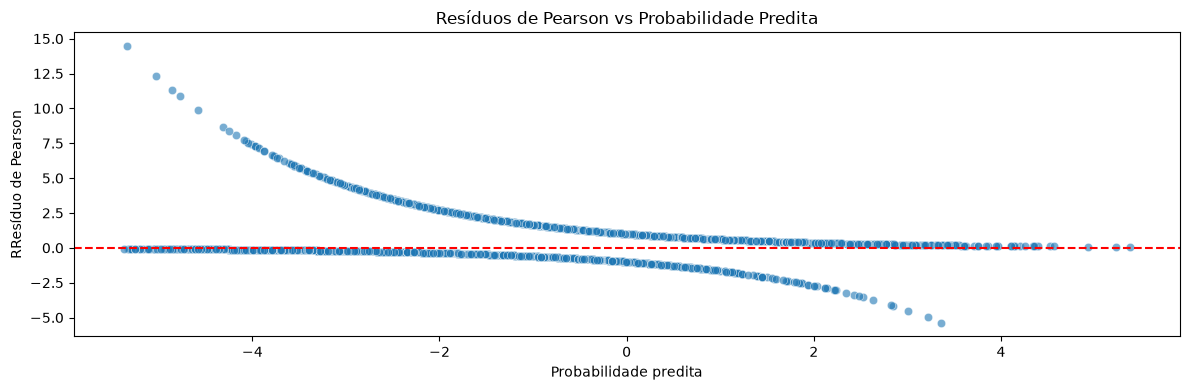

In [32]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12, 4))

sns.scatterplot(x=modelo_base.fittedvalues, y=modelo_base.resid_pearson, alpha=0.6)
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Resíduos de Pearson vs Probabilidade Predita")
plt.xlabel("Probabilidade predita")
plt.ylabel("RResíduo de Pearson")



plt.tight_layout()
plt.show()



Os diagnósticos baseados em resíduos de Deviance, resíduos de Pearson, leverage e Cook's Distance não evidenciaram observações influentes ou padrões sistemáticos de inadequação do modelo. Os maiores resíduos corresponderam a clientes pertencentes a segmentos de baixa probabilidade empírica de churn, indicando que os erros extremos decorrem de eventos raros e não da presença de observações atípicas. Assim, os resultados sugerem que eventuais melhorias no desempenho do modelo devem ser buscadas por meio do refinamento da sua especificação, como a inclusão de termos de interação teoricamente plausíveis, em vez da remoção de observações.

# Ajustes do Modelo

## Experimento 1 — Age × Geography

EDA mostrou que:

* Alemanha possui churn muito superior.
* Idade é um dos maiores preditores.
* É perfeitamente plausível que o efeito da idade seja diferente entre países.

In [33]:
formula_inter1 = """
Exited ~ CreditScore
+ Age
+ Tenure
+ Balance
+ C(Geography)
+ C(Gender)
+ ProductsGroup
+ HasCrCard
+ IsActiveMember
+ EstimatedSalary
+ Age:C(Geography)
"""

modelo_inter1 = smf.logit(
    formula=formula_inter1,
    data=df
).fit()

modelo_inter1.summary()

Optimization terminated successfully.
         Current function value: 0.372128
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 Exited   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9985
Method:                           MLE   Df Model:                           14
Date:                Sun, 19 Jul 2026   Pseudo R-squ.:                  0.2638
Time:                        15:00:28   Log-Likelihood:                -3721.3
converged:                       True   LL-Null:                       -5054.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -2.8676      0.279    -10.288      0.000      -3.414      -2.321
C(Geography)[T.Germany]         0.7703      0.274      2.810      0.005       0.233       1.307
C(Geography)[T.Spain]           0.4693      0.294      1.594      0.111      -0.108       1.046
C(Gender)[T.Male]              -0.5258      0.059     -8.917      0.000      -0.641      -0.410
ProductsGroup[T.2]             -1.5472      0.071    -21.688      0.000      -1.687      -1.407
ProductsGroup[T.3+]             2.7924      0.174     16.003      0.000       2.450       3.134
CreditScore                    -0.0007      0.000     -2.251      0.024      -0.001   -8.83e-05
Age                             0.0725      0.004     18.294      0.000       0.065       0.080
Age:C(Geography)[T.Germany]     0.0043      0.006      0.676      0.499      -0.008       0.017
Age:C(Geography)[T.Spain]      -0.0098      0.007     -1.459      0.144      -0.023       0.003
Tenure                         -0.0193      0.010     -1.913      0.056      -0.039       0.000
Balance                     -6.461e-07   5.69e-07     -1.136      0.256   -1.76e-06    4.69e-07
HasCrCard                      -0.0638      0.064     -0.995      0.320      -0.189       0.062
IsActiveMember                 -1.1007      0.062    -17.648      0.000      -1.223      -0.978
EstimatedSalary               4.69e-07   5.13e-07      0.913      0.361   -5.37e-07    1.48e-06
===============================================================================================
"""

In [34]:
resultado_inter1 = comparar_modelos(
    modelo_base, modelo_inter1, nome_candidato="Interação: Age × Geography"
)

,Log-verossimilhança,Parâmetros,AIC,ΔAIC vs. base,BIC,ΔBIC vs. base
Modelo base,-3723.170,13,7472.340,+0.000,7566.074,+0.000
Interação: Age × Geography,-3721.284,15,7472.567,+0.228,7580.722,+14.648


,LR (χ²),gl,p-valor,Decisão
Interação: Age × Geography vs. Modelo base,3.772,2,1.517e-01,Sem evidência de melhora sobre o modelo base (p ≥ 0.05).


Considerando os resultados da análise exploratória, foi levantada a hipótese de que o efeito da idade sobre a probabilidade de churn poderia variar entre os diferentes países. Para investigar essa possibilidade, foram adicionados termos de interação entre Age e Geography ao modelo. Entretanto, nenhuma das interações apresentou significância estatística (Alemanha: p = 0,499; Espanha: p = 0,144). Além disso, o teste da razão de verossimilhanças (LR = 3,772; gl = 2; p = 0,152) não indicou melhoria significativa do ajuste. Os critérios AIC e BIC também apresentaram ligeiro aumento, evidenciando que a inclusão desses termos apenas aumentou a complexidade do modelo sem ganhos explicativos. Dessa forma, optou-se por manter a especificação mais parcimoniosa.

## Experimento 2 — Balance × Geography

EDA mostrou que:

* Alemanha apresenta um comportamento completamente diferente em relação ao saldo médio.
* França e Espanha concentram muitos clientes com saldo zero;


In [35]:
formula_inter2 = """
Exited ~ CreditScore
+ Age
+ Tenure
+ Balance
+ C(Geography)
+ C(Gender)
+ ProductsGroup
+ HasCrCard
+ IsActiveMember
+ EstimatedSalary
+ Balance:C(Geography)
"""

modelo_inter2 = smf.logit(
    formula=formula_inter2,
    data=df
).fit()

modelo_inter2.summary()

Optimization terminated successfully.
         Current function value: 0.372271
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 Exited   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9985
Method:                           MLE   Df Model:                           14
Date:                Sun, 19 Jul 2026   Pseudo R-squ.:                  0.2635
Time:                        15:00:28   Log-Likelihood:                -3722.7
converged:                       True   LL-Null:                       -5054.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
===================================================================================================
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -2.7920      0.253    -11.015      0.000      -3.289      -2.295
C(Geography)[T.Germany]             0.7302      0.248      2.944      0.003       0.244       1.216
C(Geography)[T.Spain]               0.0172      0.116      0.149      0.882      -0.209       0.244
C(Gender)[T.Male]                  -0.5247      0.059     -8.903      0.000      -0.640      -0.409
ProductsGroup[T.2]                 -1.5500      0.071    -21.690      0.000      -1.690      -1.410
ProductsGroup[T.3+]                 2.7986      0.175     16.005      0.000       2.456       3.141
CreditScore                        -0.0007      0.000     -2.256      0.024      -0.001   -8.98e-05
Age                                 0.0714      0.003     25.846      0.000       0.066       0.077
Tenure                             -0.0191      0.010     -1.892      0.059      -0.039       0.001
Balance                         -9.662e-07   7.21e-07     -1.340      0.180   -2.38e-06    4.47e-07
Balance:C(Geography)[T.Germany]  1.932e-06   2.07e-06      0.933      0.351   -2.12e-06    5.99e-06
Balance:C(Geography)[T.Spain]    4.873e-07   1.19e-06      0.408      0.683   -1.85e-06    2.83e-06
HasCrCard                          -0.0665      0.064     -1.037      0.300      -0.192       0.059
IsActiveMember                     -1.1047      0.062    -17.720      0.000      -1.227      -0.982
EstimatedSalary                  4.454e-07   5.13e-07      0.868      0.385    -5.6e-07    1.45e-06
===================================================================================================
"""

In [36]:
resultado_inter2 = comparar_modelos(
    modelo_base, modelo_inter2, nome_candidato="Interação: Balance × Geography"
)

,Log-verossimilhança,Parâmetros,AIC,ΔAIC vs. base,BIC,ΔBIC vs. base
Modelo base,-3723.170,13,7472.340,+0.000,7566.074,+0.000
Interação: Balance × Geography,-3722.708,15,7475.415,+3.076,7583.570,+17.496


,LR (χ²),gl,p-valor,Decisão
Interação: Balance × Geography vs. Modelo base,0.924,2,6.299e-01,Sem evidência de melhora sobre o modelo base (p ≥ 0.05).


Não foram encontradas evidências de que a inclusão de termos de interação entre as variáveis avaliadas produzisse melhoria significativa no ajuste do modelo

## Refinamento via forma funcional

### Modelo Age Quadrática

In [37]:
df["Age2"] = df["Age"]**2

In [38]:
formula_refinamento_1 = """
Exited ~ CreditScore
+ Age
+ Age2
+ Tenure
+ Balance
+ C(Geography)
+ C(Gender)
+ ProductsGroup
+ HasCrCard
+ IsActiveMember
+ EstimatedSalary
"""

modelo_refinamento_1 = smf.logit(
    formula=formula_refinamento_1,
    data=df
).fit()

modelo_refinamento_1.summary()

Optimization terminated successfully.
         Current function value: 0.360555
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 Exited   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9986
Method:                           MLE   Df Model:                           13
Date:                Sun, 19 Jul 2026   Pseudo R-squ.:                  0.2867
Time:                        15:00:28   Log-Likelihood:                -3605.5
converged:                       True   LL-Null:                       -5054.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -9.0882      0.522    -17.414      0.000     -10.111      -8.065
C(Geography)[T.Germany]     0.9328      0.074     12.574      0.000       0.787       1.078
C(Geography)[T.Spain]       0.0359      0.077      0.468      0.640      -0.114       0.186
C(Gender)[T.Male]          -0.5245      0.060     -8.780      0.000      -0.642      -0.407
ProductsGroup[T.2]         -1.5184      0.071    -21.245      0.000      -1.658      -1.378
ProductsGroup[T.3+]         2.8696      0.184     15.625      0.000       2.510       3.230
CreditScore                -0.0006      0.000     -1.993      0.046      -0.001   -1.03e-05
Age                         0.3496      0.020     17.279      0.000       0.310       0.389
Age2                       -0.0030      0.000    -13.931      0.000      -0.003      -0.003
Tenure                     -0.0188      0.010     -1.835      0.067      -0.039       0.001
Balance                 -6.684e-07   5.74e-07     -1.165      0.244   -1.79e-06    4.57e-07
HasCrCard                  -0.0528      0.065     -0.812      0.417      -0.180       0.075
IsActiveMember             -0.9926      0.063    -15.870      0.000      -1.115      -0.870
EstimatedSalary          4.342e-07   5.21e-07      0.834      0.404   -5.86e-07    1.45e-06
===========================================================================================
"""

In [39]:
resultado_refinamento_1 = comparar_modelos(
    modelo_base, modelo_refinamento_1, nome_candidato="Refinamento: idade quadrática"
)

,Log-verossimilhança,Parâmetros,AIC,ΔAIC vs. base,BIC,ΔBIC vs. base
Modelo base,-3723.170,13,7472.340,+0.000,7566.074,+0.000
Refinamento: idade quadrática,-3605.548,14,7239.096,-233.244,7340.041,-226.034


,LR (χ²),gl,p-valor,Decisão
Refinamento: idade quadrática vs. Modelo base,235.244,1,4.283e-53,Evidência de melhora sobre o modelo base (p < 0.05).


A análise dos pressupostos identificou violação da linearidade no logito para a variável Age. Inicialmente foram avaliadas hipóteses de interação entre variáveis explicativas, porém nenhuma resultou em melhoria significativa do ajuste. Em seguida, optou-se por refinar a forma funcional da idade por meio da inclusão de um termo quadrático, hipótese diretamente motivada pelo diagnóstico de Box-Tidwell. O modelo refinado apresentou melhora substancial da log-verossimilhança (ΔLL = 117,6), redução expressiva dos critérios AIC (ΔAIC = −233,2) e BIC (ΔBIC = −226,0), além de evidência altamente significativa no teste da razão de verossimilhanças (χ² = 235,24; gl = 1; p < 0,001). Esses resultados indicam que a relação entre idade e probabilidade de churn é não linear, sendo mais adequadamente representada por uma função quadrática do que por um termo linear simples.

#### Diagnostico Modelo Age Quadrática

O diagnóstico abaixo compara o modelo base com o modelo que inclui `Age²`. A leitura está organizada em três perguntas:

* O ajuste dos resíduos melhorou de forma agregada?
* Houve melhora no comportamento global dos resíduos?
* Quais aspetos permaneceram inalterados e quais tipos de observações continuaram produzindo maiores discrepâncias?

In [40]:
df_Age_2 = df.copy()

df_Age_2["Probabilidade_Prevista"] = modelo_refinamento_1.predict(df)
df_Age_2["Residuo_Deviance"] = modelo_refinamento_1.resid_dev
df_Age_2["Residuo_Pearson"] = modelo_refinamento_1.resid_pearson

influencia = modelo_refinamento_1.get_influence()

df_Age_2["Leverage"] = influencia.hat_matrix_diag
df_Age_2["Cooks_Distance"] = influencia.cooks_distance[0]


##### Comparação agregada dos resíduos

In [41]:
variaveis_diagnostico = [
    "Probabilidade_Prevista",
    "Residuo_Deviance",
    "Residuo_Pearson",
    "Leverage",
    "Cooks_Distance",
]

def resumir_diagnostico(dados, variaveis):
    resumo = dados[variaveis].agg(["mean", "std", "median", "min", "max"]).T
    resumo["p95_abs"] = dados[variaveis].abs().quantile(0.95)
    resumo["max_abs"] = dados[variaveis].abs().max()
    return resumo.rename(columns={
        "mean": "media",
        "std": "desvio",
        "median": "mediana",
        "min": "minimo",
        "max": "maximo",
    })

resumo_base = resumir_diagnostico(df, variaveis_diagnostico)
resumo_age2 = resumir_diagnostico(df_Age_2, variaveis_diagnostico)

resumo_comparativo = pd.concat(
    {"Modelo base": resumo_base, "Modelo Age²": resumo_age2},
    names=["Modelo", "Metrica"]
).reset_index()

resumo_comparativo.style.format({
    "media": "{:.6f}",
    "desvio": "{:.6f}",
    "mediana": "{:.6f}",
    "minimo": "{:.6f}",
    "maximo": "{:.6f}",
    "p95_abs": "{:.6f}",
    "max_abs": "{:.6f}",
})


,Modelo,Metrica,media,desvio,mediana,minimo,maximo,p95_abs,max_abs
0,Modelo base,Probabilidade_Prevista,0.203700,0.215252,0.117287,0.004621,0.995394,0.692273,0.995394
1,Modelo base,Residuo_Deviance,-0.130674,0.853013,-0.360409,-2.605591,3.270450,1.827346,3.270450
2,Modelo base,Residuo_Pearson,0.001754,1.026852,-0.259042,-5.366682,14.462739,2.076060,14.462739
3,Modelo base,Leverage,0.001300,0.001058,0.001055,0.000077,0.011011,0.003015,0.011011
4,Modelo base,Cooks_Distance,0.000103,0.000225,0.000012,0.000000,0.003087,0.000562,0.003087
5,Modelo Age²,Probabilidade_Prevista,0.203700,0.222581,0.113910,0.000606,0.990737,0.697466,0.990737
6,Modelo Age²,Residuo_Deviance,-0.121507,0.840486,-0.338880,-2.709122,3.836742,1.788793,3.836742
7,Modelo Age²,Residuo_Pearson,0.024030,1.204988,-0.243105,-6.183766,39.639648,1.988087,39.639648
8,Modelo Age²,Leverage,0.001400,0.001253,0.001140,0.000026,0.020808,0.003235,0.020808
9,Modelo Age²,Cooks_Distance,0.000103,0.000249,0.000012,0.000000,0.003894,0.000538,0.003894


In [42]:
metricas_delta = ["Residuo_Deviance", "Residuo_Pearson", "Leverage", "Cooks_Distance"]

comparacao_delta = pd.DataFrame({
    "desvio_base": resumo_base.loc[metricas_delta, "desvio"],
    "desvio_age2": resumo_age2.loc[metricas_delta, "desvio"],
    "delta_desvio": resumo_age2.loc[metricas_delta, "desvio"] - resumo_base.loc[metricas_delta, "desvio"],
    "p95_abs_base": resumo_base.loc[metricas_delta, "p95_abs"],
    "p95_abs_age2": resumo_age2.loc[metricas_delta, "p95_abs"],
    "delta_p95_abs": resumo_age2.loc[metricas_delta, "p95_abs"] - resumo_base.loc[metricas_delta, "p95_abs"],
    "max_abs_base": resumo_base.loc[metricas_delta, "max_abs"],
    "max_abs_age2": resumo_age2.loc[metricas_delta, "max_abs"],
    "delta_max_abs": resumo_age2.loc[metricas_delta, "max_abs"] - resumo_base.loc[metricas_delta, "max_abs"],
})

comparacao_delta.style.format("{:.6f}").set_caption(
    "Variação do diagnóstico: valores negativos indicam redução no modelo com Age²"
)


,desvio_base,desvio_age2,delta_desvio,p95_abs_base,p95_abs_age2,delta_p95_abs,max_abs_base,max_abs_age2,delta_max_abs
Residuo_Deviance,0.853013,0.840486,-0.012527,1.827346,1.788793,-0.038553,3.270450,3.836742,0.566293
Residuo_Pearson,1.026852,1.204988,0.178136,2.076060,1.988087,-0.087973,14.462739,39.639648,25.176908
Leverage,0.001058,0.001253,0.000195,0.003015,0.003235,0.000220,0.011011,0.020808,0.009797
Cooks_Distance,0.000225,0.000249,0.000024,0.000562,0.000538,-0.000024,0.003087,0.003894,0.000807


A tabela de deltas separa a melhora média da presença de casos extremos. Essa distinção é importante porque o modelo com `Age²` pode reduzir a dispersão dos resíduos de deviance para a massa central das observações e, ao mesmo tempo, aumentar resíduos de Pearson em poucos clientes com evento observado e probabilidade prevista muito baixa.

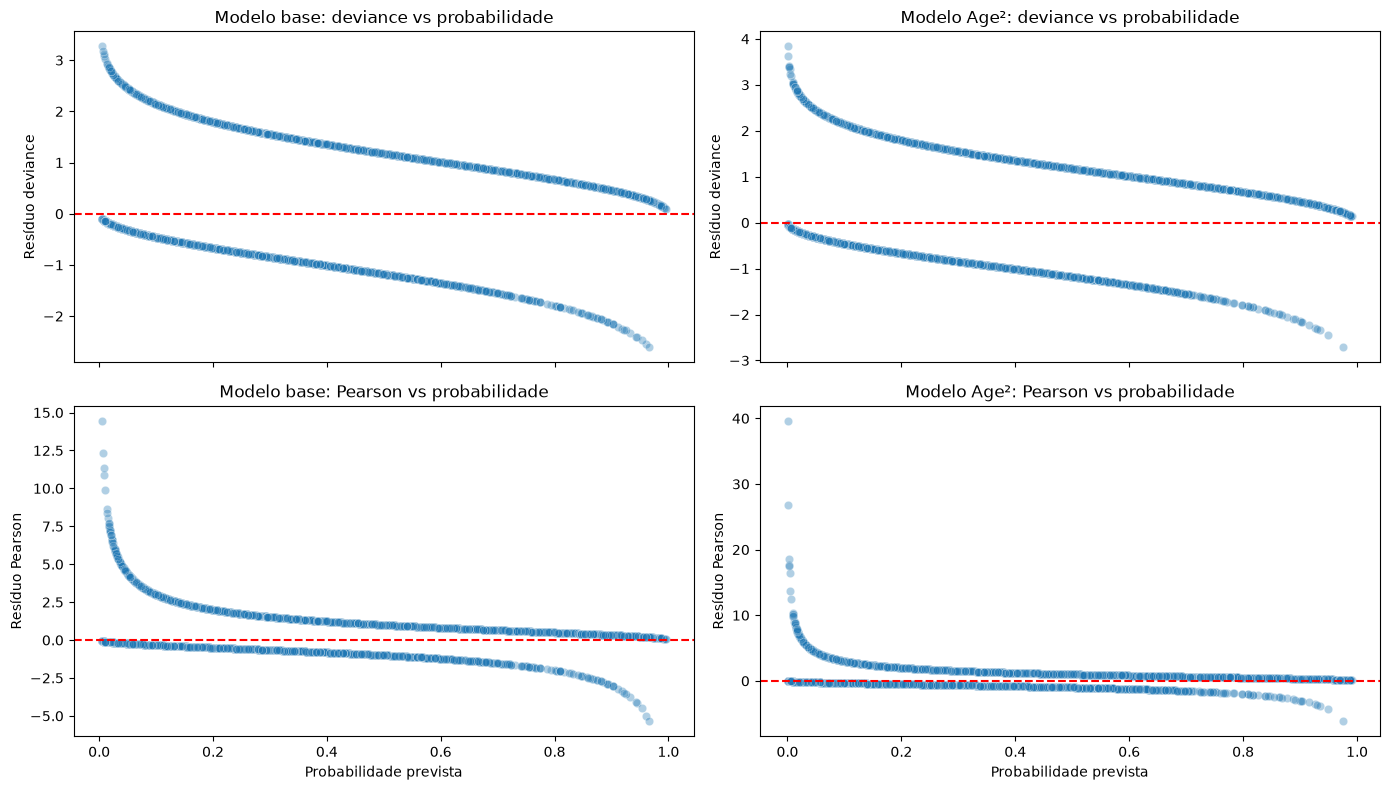

In [43]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8), sharex='col')

sns.scatterplot(
    x=df["Probabilidade_Prevista"],
    y=df["Residuo_Deviance"],
    alpha=0.35,
    ax=axes[0, 0],
)
axes[0, 0].axhline(y=0, color="red", linestyle="--")
axes[0, 0].set_title("Modelo base: deviance vs probabilidade")
axes[0, 0].set_ylabel("Resíduo deviance")

sns.scatterplot(
    x=df_Age_2["Probabilidade_Prevista"],
    y=df_Age_2["Residuo_Deviance"],
    alpha=0.35,
    ax=axes[0, 1],
)
axes[0, 1].axhline(y=0, color="red", linestyle="--")
axes[0, 1].set_title("Modelo Age²: deviance vs probabilidade")
axes[0, 1].set_ylabel("Resíduo deviance")

sns.scatterplot(
    x=df["Probabilidade_Prevista"],
    y=df["Residuo_Pearson"],
    alpha=0.35,
    ax=axes[1, 0],
)
axes[1, 0].axhline(y=0, color="red", linestyle="--")
axes[1, 0].set_title("Modelo base: Pearson vs probabilidade")
axes[1, 0].set_xlabel("Probabilidade prevista")
axes[1, 0].set_ylabel("Resíduo Pearson")

sns.scatterplot(
    x=df_Age_2["Probabilidade_Prevista"],
    y=df_Age_2["Residuo_Pearson"],
    alpha=0.35,
    ax=axes[1, 1],
)
axes[1, 1].axhline(y=0, color="red", linestyle="--")
axes[1, 1].set_title("Modelo Age²: Pearson vs probabilidade")
axes[1, 1].set_xlabel("Probabilidade prevista")
axes[1, 1].set_ylabel("Resíduo Pearson")

plt.tight_layout()
plt.show()


In [44]:
df_comparacao_residuos = pd.DataFrame({
    "Age": df["Age"],
    "Exited": df["Exited"],
    "Pearson Base": df["Residuo_Pearson"],
    "Pearson Age²": df_Age_2["Residuo_Pearson"],
    "Deviance Base": df["Residuo_Deviance"],
    "Deviance Age²": df_Age_2["Residuo_Deviance"],
    "Prob Base": df["Probabilidade_Prevista"],
    "Prob Age²": df_Age_2["Probabilidade_Prevista"],
})

df_comparacao_residuos["Faixa_Idade"] = pd.cut(
    df_comparacao_residuos["Age"],
    bins=[17, 25, 35, 45, 55, 65, 100],
)

resumo_por_idade = (
    df_comparacao_residuos
    .assign(
        abs_pearson_base=lambda dados: dados["Pearson Base"].abs(),
        abs_pearson_age2=lambda dados: dados["Pearson Age²"].abs(),
        abs_deviance_base=lambda dados: dados["Deviance Base"].abs(),
        abs_deviance_age2=lambda dados: dados["Deviance Age²"].abs(),
    )
    .groupby("Faixa_Idade", observed=True)
    .agg(
        qtd=("Age", "size"),
        taxa_churn=("Exited", "mean"),
        prob_media_base=("Prob Base", "mean"),
        prob_media_age2=("Prob Age²", "mean"),
        abs_pearson_base=("abs_pearson_base", "mean"),
        abs_pearson_age2=("abs_pearson_age2", "mean"),
        abs_deviance_base=("abs_deviance_base", "mean"),
        abs_deviance_age2=("abs_deviance_age2", "mean"),
    )
)

resumo_por_idade["delta_prob_media"] = resumo_por_idade["prob_media_age2"] - resumo_por_idade["prob_media_base"]
resumo_por_idade["delta_abs_pearson"] = resumo_por_idade["abs_pearson_age2"] - resumo_por_idade["abs_pearson_base"]
resumo_por_idade["delta_abs_deviance"] = resumo_por_idade["abs_deviance_age2"] - resumo_por_idade["abs_deviance_base"]

resumo_por_idade.style.format({
    "taxa_churn": "{:.2%}",
    "prob_media_base": "{:.2%}",
    "prob_media_age2": "{:.2%}",
    "delta_prob_media": "{:+.2%}",
    "abs_pearson_base": "{:.4f}",
    "abs_pearson_age2": "{:.4f}",
    "delta_abs_pearson": "{:+.4f}",
    "abs_deviance_base": "{:.4f}",
    "abs_deviance_age2": "{:.4f}",
    "delta_abs_deviance": "{:+.4f}",
})


,qtd,taxa_churn,prob_media_base,prob_media_age2,abs_pearson_base,abs_pearson_age2,abs_deviance_base,abs_deviance_age2,delta_prob_media,delta_abs_pearson,delta_abs_deviance
Faixa_Idade,,,,,,,,,,,
"(17, 25]",611,7.53%,6.93%,2.34%,0.4831,0.6724,0.4447,0.3486,-4.59%,+0.1894,-0.0961
"(25, 35]",3542,8.50%,11.27%,8.78%,0.4889,0.4886,0.5294,0.4855,-2.49%,-0.0004,-0.0439
"(35, 45]",3736,19.62%,20.04%,22.85%,0.6753,0.6757,0.7301,0.7540,+2.81%,+0.0004,+0.0239
"(45, 55]",1311,50.57%,36.55%,42.66%,0.8715,0.8272,0.9526,0.9440,+6.11%,-0.0443,-0.0087
"(55, 65]",536,48.32%,44.24%,42.96%,0.7955,0.7927,0.9135,0.9134,-1.28%,-0.0028,-0.0001
"(65, 100]",264,13.26%,49.53%,25.92%,1.0343,0.6331,1.1018,0.7497,-23.60%,-0.4012,-0.3521


##### Observações com maiores resíduos

In [45]:
top10_person_resid_mod_base = df.assign(
    abs_pears=np.abs(df["Residuo_Pearson"])
).nlargest(10, "abs_pears")

top10_person_resid_modelo_ajust = df_Age_2.assign(
    abs_pears=np.abs(df_Age_2["Residuo_Pearson"])
).nlargest(10, "abs_pears")

idx_base = set(top10_person_resid_mod_base.index)
idx_age2 = set(top10_person_resid_modelo_ajust.index)

resumo_overlap = pd.DataFrame({
    "Grupo": ["Top 10 em comum", "Somente no modelo base", "Somente no modelo Age²"],
    "Quantidade": [
        len(idx_base & idx_age2),
        len(idx_base - idx_age2),
        len(idx_age2 - idx_base),
    ],
})

resumo_overlap


,Grupo,Quantidade
0,Top 10 em comum,7
1,Somente no modelo base,3
2,Somente no modelo Age²,3


In [46]:
colunas_cliente = [
    "CreditScore",
    "Geography",
    "Gender",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary",
    "Exited",
]

comparacao_mesmos_clientes = (
    df[colunas_cliente + ["Probabilidade_Prevista", "Residuo_Pearson", "Residuo_Deviance"]]
    .rename(columns={
        "Probabilidade_Prevista": "Prob_Base",
        "Residuo_Pearson": "Pearson_Base",
        "Residuo_Deviance": "Deviance_Base",
    })
    .join(
        df_Age_2[["Probabilidade_Prevista", "Residuo_Pearson", "Residuo_Deviance"]]
        .rename(columns={
            "Probabilidade_Prevista": "Prob_Age2",
            "Residuo_Pearson": "Pearson_Age2",
            "Residuo_Deviance": "Deviance_Age2",
        })
    )
)

comparacao_mesmos_clientes["Delta_Prob"] = comparacao_mesmos_clientes["Prob_Age2"] - comparacao_mesmos_clientes["Prob_Base"]
comparacao_mesmos_clientes["Delta_Abs_Pearson"] = comparacao_mesmos_clientes["Pearson_Age2"].abs() - comparacao_mesmos_clientes["Pearson_Base"].abs()
comparacao_mesmos_clientes["Delta_Abs_Deviance"] = comparacao_mesmos_clientes["Deviance_Age2"].abs() - comparacao_mesmos_clientes["Deviance_Base"].abs()

comparacao_mesmos_clientes.sort_values(
    "Delta_Abs_Pearson",
    ascending=False,
).head(10).style.format({
    "Balance": "{:.2f}",
    "EstimatedSalary": "{:.2f}",
    "Prob_Base": "{:.4%}",
    "Prob_Age2": "{:.4%}",
    "Delta_Prob": "{:+.4%}",
    "Pearson_Base": "{:.4f}",
    "Pearson_Age2": "{:.4f}",
    "Delta_Abs_Pearson": "{:+.4f}",
    "Deviance_Base": "{:.4f}",
    "Deviance_Age2": "{:.4f}",
    "Delta_Abs_Deviance": "{:+.4f}",
})


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Prob_Base,Pearson_Base,Deviance_Base,Prob_Age2,Pearson_Age2,Deviance_Age2,Delta_Prob,Delta_Abs_Pearson,Delta_Abs_Deviance
2141,674,France,Male,18,7,0.00,2,1,1,55753.12,1,0.4758%,14.4627,3.2704,0.0636%,39.6396,3.8367,-0.4122%,+25.1769,+0.5663
7353,596,France,Male,21,4,210433.08,2,0,1,197297.77,1,0.6522%,12.3422,3.1726,0.1388%,26.8237,3.6277,-0.5134%,+14.4815,+0.4551
9572,644,Spain,Male,18,7,0.00,1,0,1,59645.24,1,2.5128%,6.2286,2.7143,0.3228%,17.5714,3.3870,-2.1900%,+11.3428,+0.6727
1827,425,Spain,Female,22,7,169649.73,2,0,1,136365.00,1,1.3178%,8.6537,2.9425,0.3184%,17.6925,3.3910,-0.9993%,+9.0388,+0.4485
6596,477,France,Male,22,5,82559.42,2,0,0,163112.90,1,2.3668%,6.4227,2.7363,0.5280%,13.7263,3.2385,-1.8389%,+7.3036,+0.5022
7017,646,Spain,Male,25,5,182876.88,2,1,1,42537.59,1,0.7711%,11.3440,3.1193,0.2906%,18.5245,3.4179,-0.4805%,+7.1805,+0.2986
4922,702,France,Male,26,5,56738.47,2,1,1,100442.22,1,0.8409%,10.8591,3.0914,0.3685%,16.4433,3.3477,-0.4724%,+5.5842,+0.2563
4981,667,Spain,Female,23,6,136100.69,2,0,0,169669.33,1,3.7212%,5.0865,2.5656,0.9667%,10.1217,3.0460,-2.7546%,+5.0352,+0.4804
4218,589,Germany,Female,19,9,83495.11,1,1,1,143022.31,1,9.5418%,3.0790,2.1677,1.5566%,7.9526,2.8854,-7.9853%,+4.8736,+0.7177
5936,588,Spain,Female,22,9,67178.19,1,1,1,163534.75,1,5.1725%,4.2817,2.4339,1.2899%,8.7480,2.9498,-3.8826%,+4.4663,+0.5159


In [47]:
perfil_top10 = pd.concat(
    [
        top10_person_resid_mod_base.assign(Modelo="Modelo base"),
        top10_person_resid_modelo_ajust.assign(Modelo="Modelo Age²"),
    ],
    ignore_index=True,
)

perfil_categorico_top10 = (
    perfil_top10
    .groupby("Modelo")
    .agg(
        qtd=("Exited", "size"),
        churn=("Exited", "sum"),
        idade_media=("Age", "mean"),
        prob_media=("Probabilidade_Prevista", "mean"),
        pearson_abs_medio=("abs_pears", "mean"),
    )
)

display(perfil_categorico_top10.style.format({
    "idade_media": "{:.1f}",
    "prob_media": "{:.2%}",
    "pearson_abs_medio": "{:.2f}",
}))

display(pd.crosstab(perfil_top10["Modelo"], perfil_top10["Gender"]))
display(pd.crosstab(perfil_top10["Modelo"], perfil_top10["Geography"]))


,qtd,churn,idade_media,prob_media,pearson_abs_medio
Modelo,,,,,
Modelo Age²,10,10,23.2,0.46%,18.34
Modelo base,10,10,27.0,1.13%,9.93


Gender,Female,Male
Modelo,,
Modelo Age²,3,7
Modelo base,2,8


Geography,France,Spain
Modelo,,
Modelo Age²,6,4
Modelo base,8,2


A inclusão do termo quadrático para a idade melhorou significativamente o ajuste global do modelo, conforme evidenciado pelo aumento da log-verossimilhança e pela redução dos critérios AIC e BIC. No diagnóstico dos resíduos, a comparação deve ser lida como um trade-off: os resíduos de deviance indicam melhor ajuste para a massa central das observações, enquanto alguns resíduos de Pearson aumentam quando o modelo atribui probabilidade muito baixa a clientes que efetivamente apresentaram churn.

A comparação dos mesmos clientes torna esse ponto mais claro. Se boa parte do `top 10` de resíduos permanece nos dois modelos, a reespecificação de idade corrige a não linearidade global, mas não explica completamente esses perfis extremos. Esses casos parecem depender de informações ausentes no conjunto de dados ou de heterogeneidade não capturada pelas variáveis atuais, e não apenas da forma funcional de `Age`.

#### Conclusões do diagnóstico do modelo refinado

O modelo apresentou melhora significativa no ajuste global, evidenciada pela redução do AIC e do BIC e pelo aumento da log-verossimilhança;
os resíduos de deviance apresentaram menor dispersão, indicando melhor ajuste para a maioria das observações;
os resíduos de Pearson permaneceram elevados para um pequeno conjunto de clientes jovens com churn observado e baixa probabilidade prevista;
a comparação entre o modelo base e o modelo refinado mostrou que esses clientes permaneceram praticamente os mesmos, indicando que essas discrepâncias não decorrem da especificação linear da idade, mas provavelmente da ausência de variáveis relevantes no conjunto de dados.

| Refinamento         | Hipótese                        | Resultado |
|---------------------|---------------------------------|-----------|
| Age × Geography     | efeito da idade depende do país | rejeitado |
| Balance × Geography | efeito do saldo depende do país | rejeitado |
| Age²                | relação não linear              | aceito    |


# Modelo Final

In [48]:
formula_modelo_final = """
Exited ~ CreditScore
+ Age
+ Age2
+ Tenure
+ Balance
+ C(Geography)
+ C(Gender)
+ ProductsGroup
+ HasCrCard
+ IsActiveMember
+ EstimatedSalary
"""

modelo_final = smf.logit(
    formula=formula_modelo_final,
    data=df
).fit()

modelo_final.summary()

Optimization terminated successfully.
         Current function value: 0.360555
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 Exited   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9986
Method:                           MLE   Df Model:                           13
Date:                Sun, 19 Jul 2026   Pseudo R-squ.:                  0.2867
Time:                        15:00:29   Log-Likelihood:                -3605.5
converged:                       True   LL-Null:                       -5054.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -9.0882      0.522    -17.414      0.000     -10.111      -8.065
C(Geography)[T.Germany]     0.9328      0.074     12.574      0.000       0.787       1.078
C(Geography)[T.Spain]       0.0359      0.077      0.468      0.640      -0.114       0.186
C(Gender)[T.Male]          -0.5245      0.060     -8.780      0.000      -0.642      -0.407
ProductsGroup[T.2]         -1.5184      0.071    -21.245      0.000      -1.658      -1.378
ProductsGroup[T.3+]         2.8696      0.184     15.625      0.000       2.510       3.230
CreditScore                -0.0006      0.000     -1.993      0.046      -0.001   -1.03e-05
Age                         0.3496      0.020     17.279      0.000       0.310       0.389
Age2                       -0.0030      0.000    -13.931      0.000      -0.003      -0.003
Tenure                     -0.0188      0.010     -1.835      0.067      -0.039       0.001
Balance                 -6.684e-07   5.74e-07     -1.165      0.244   -1.79e-06    4.57e-07
HasCrCard                  -0.0528      0.065     -0.812      0.417      -0.180       0.075
IsActiveMember             -0.9926      0.063    -15.870      0.000      -1.115      -0.870
EstimatedSalary          4.342e-07   5.21e-07      0.834      0.404   -5.86e-07    1.45e-06
===========================================================================================
"""

## Interpretação Final dos Coeficientes

In [49]:
coeficientes_final = pd.DataFrame({
    "Coeficiente": modelo_final.params,
    "p-valor": modelo_final.pvalues,
})

ic95 = modelo_final.conf_int()
coeficientes_final["OR"] = np.exp(coeficientes_final["Coeficiente"])
coeficientes_final["IC95%"] = ic95.apply(
    lambda intervalo: f"[{np.exp(intervalo.iloc[0]):.3f}; {np.exp(intervalo.iloc[1]):.3f}]",
    axis=1
)

def classificar_significancia(p_valor):
    if p_valor < 0.001:
        return "***"
    if p_valor < 0.01:
        return "**"
    if p_valor < 0.05:
        return "*"
    if p_valor < 0.10:
        return "."
    return "ns"

def interpretar_efeito_pratico(or_valor):
    if or_valor >= 2:
        return "Aumenta fortemente a chance de churn"
    if or_valor >= 1.2:
        return "Aumenta moderadamente a chance de churn"
    if or_valor > 1:
        return "Aumenta pouco a chance de churn"
    if or_valor <= 0.5:
        return "Reduz fortemente a chance de churn"
    if or_valor <= 0.8:
        return "Reduz moderadamente a chance de churn"
    return "Efeito prático pequeno"

tabela_interpretacao_coeficientes = (
    coeficientes_final
    .assign(
        Significancia=lambda dados: dados["p-valor"].apply(classificar_significancia),
        **{"Efeito prático": lambda dados: dados["OR"].apply(interpretar_efeito_pratico)}
    )
    .drop(columns="Coeficiente")
    .rename_axis("Variável")
    .reset_index()
    [["Variável", "OR", "IC95%", "Significancia", "Efeito prático", "p-valor"]]
)

tabela_interpretacao_coeficientes.style.format({
    "OR": "{:.3f}",
    "p-valor": "{:.4f}",
})


,Variável,OR,IC95%,Significancia,Efeito prático,p-valor
0,Intercept,0.000,[0.000; 0.000],***,Reduz fortemente a chance de churn,0.0000
1,C(Geography)[T.Germany],2.542,[2.198; 2.939],***,Aumenta fortemente a chance de churn,0.0000
2,C(Geography)[T.Spain],1.037,[0.892; 1.205],ns,Aumenta pouco a chance de churn,0.6396
3,C(Gender)[T.Male],0.592,[0.526; 0.665],***,Reduz moderadamente a chance de churn,0.0000
4,ProductsGroup[T.2],0.219,[0.190; 0.252],***,Reduz fortemente a chance de churn,0.0000
5,ProductsGroup[T.3+],17.630,[12.300; 25.268],***,Aumenta fortemente a chance de churn,0.0000
6,CreditScore,0.999,[0.999; 1.000],*,Efeito prático pequeno,0.0462
7,Age,1.418,[1.363; 1.476],***,Aumenta moderadamente a chance de churn,0.0000
8,Age2,0.997,[0.997; 0.997],***,Efeito prático pequeno,0.0000
9,Tenure,0.981,[0.962; 1.001],.,Efeito prático pequeno,0.0666


A regressão logística indicou que HasCrCard, Balance e EstimatedSalary não apresentaram associação estatisticamente significativa com o churn ao nível de 5%. A variável Tenure apresentou evidência marginal (p = 0,0666), enquanto CreditScore, embora estatisticamente significativo (p = 0,0462), apresentou efeito prático muito pequeno (OR ≈ 0,999).

Em relação às variáveis categóricas, não foram encontradas evidências de diferença entre clientes da Espanha e da França quanto às chances de churn (OR = 1,037; p = 0,6396). Por outro lado, clientes da Alemanha apresentaram aproximadamente 154% ((2.542 - 1) × 100 = 154,2%) maiores chances de churn em comparação aos clientes da França (OR = 2,542).

Clientes do sexo masculino apresentaram aproximadamente 41% (1 - 0.592 = 0.408) menores chances de churn em relação às clientes do sexo feminino (OR = 0,592), enquanto clientes ativos apresentaram cerca de 63% (1-0.371=0.629) menores chances de churn quando comparados aos clientes inativos (OR = 0,371).

A variável idade apresentou comportamento não linear. O efeito linear positivo e o termo quadrático negativo indicam que as chances de churn aumentam com a idade, porém esse aumento ocorre de forma desacelerada nas faixas etárias mais elevadas, resultado consistente com os testes de pressupostos e os refinamentos realizados durante a modelagem.

Conforme observado anteriormente na análise exploratória, clientes com dois produtos apresentaram aproximadamente 78,1% ((1-0,219)x100) menores chances de churn (OR = 0,219). Em contraste, clientes pertencentes à categoria 3+ produtos apresentaram chances significativamente maiores de churn (OR = 17,63). Embora essa categoria apresente um intervalo de confiança relativamente amplo, decorrente do pequeno número de observações, o efeito permaneceu estatisticamente significativo.

## Métricas

<Axes: >

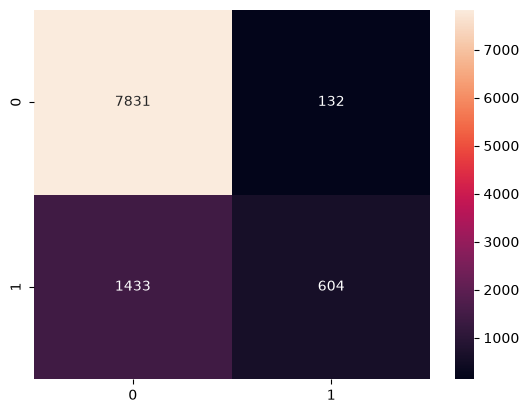

In [50]:
y_true = y
y_prob = modelo_final.fittedvalues
y_pred = (y_prob >= 0.5).astype(int)

matriz_confusao = confusion_matrix(y_true, y_pred)
sns.heatmap(matriz_confusao,annot=True,fmt="g")


In [51]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91      7963
           1       0.82      0.30      0.44      2037

    accuracy                           0.84     10000
   macro avg       0.83      0.64      0.67     10000
weighted avg       0.84      0.84      0.81     10000



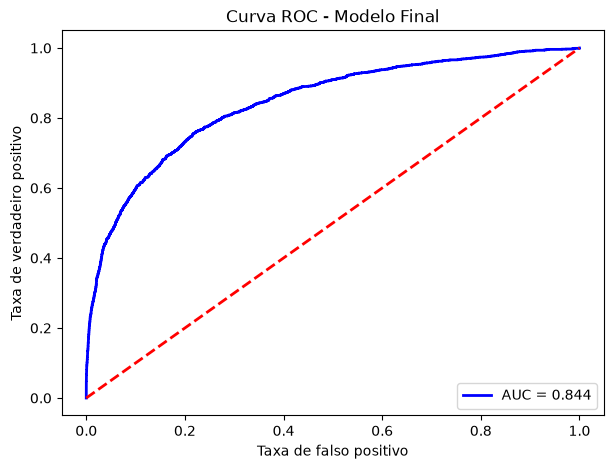

AUC: 0.8437


In [52]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--")
plt.xlabel("Taxa de falso positivo")
plt.ylabel("Taxa de verdadeiro positivo")
plt.title("Curva ROC - Modelo Final")
plt.legend(loc="lower right")
plt.show()

print(f"AUC: {roc_auc:.4f}")

O modelo apresentou acurácia de 84% e uma AUC de 0,844, indicando boa capacidade discriminatória entre clientes que realizam e que não realizam churn.

Entretanto, a matriz de confusão mostra um comportamento assimétrico. O modelo apresentou excelente desempenho para identificar clientes que permaneceram no banco (recall de 98% para a classe "não churn"), mas desempenho significativamente inferior na identificação dos clientes que efetivamente cancelaram seus serviços (recall de aproximadamente 30%).

Esse resultado é evidenciado pelo elevado número de falsos negativos (1433), ou seja, clientes que efetivamente realizaram churn, mas foram classificados pelo modelo como clientes que permaneceriam ativos. Em contrapartida, o número de falsos positivos (132) foi bastante reduzido, refletindo a elevada precisão (82%) das previsões positivas.

Essa característica indica que o modelo adota uma postura conservadora: ele evita classificar clientes como churn sem forte evidência, produzindo poucas falsas alarmes, porém deixando de identificar uma parcela considerável dos clientes que realmente abandonam o banco.

Os resultados obtidos durante a análise estatística ajudam a explicar esse comportamento. A investigação dos resíduos mostrou a existência de um pequeno conjunto de clientes sistematicamente difíceis de modelar, mesmo após a inclusão do termo quadrático para a idade. Esses clientes permaneceram entre as maiores discrepâncias do modelo, sugerindo que parte do erro decorre da ausência de variáveis de negócio relevantes — como informações comportamentais, histórico de relacionamento ou utilização dos serviços — que não estão disponíveis no conjunto de dados utilizado.

Consequentemente, embora o modelo apresente bom desempenho global e boa capacidade de discriminação (AUC = 0,844), sua utilização em produção dependeria do objetivo do negócio. Para aplicações de retenção de clientes, seria desejável aumentar o recall da classe churn, ainda que isso implique aceitar um aumento moderado no número de falsos positivos.

# Considerações Finais

Durante a construção do modelo foram avaliadas diferentes hipóteses de refinamento, incluindo interações entre variáveis e alterações na forma funcional da idade. As interações propostas não apresentaram melhora estatisticamente significativa do ajuste, enquanto a inclusão de um termo quadrático para a idade proporcionou redução expressiva dos critérios AIC e BIC e aumento da log-verossimilhança, sendo incorporada ao modelo final.

A análise dos resíduos mostrou que, embora o ajuste global tenha melhorado, um pequeno conjunto de observações permaneceu sistematicamente difícil de explicar. Esses clientes apresentavam perfis semelhantes, mas continuaram produzindo resíduos elevados mesmo após o refinamento da forma funcional da idade, sugerindo que parte do erro remanescente decorre da ausência de variáveis explicativas relevantes no conjunto de dados, e não da especificação do modelo estatístico.